# 📓 Brazil Real Estate Analysis 

---



# 1. Project Overview



## 1.1 Title and Author



**Project:** Brazil Real Estate Analysis
**Author:** Youssef Magar
**Objective:** Explore the Brazilian real estate market, analyze pricing, and understand key factors influencing home values.



## 1.2 Project Goals



This project analyzes real estate data in Brazil to explore key factors affecting housing prices.

**Main Goals:**

1. Identify the most expensive regions in Brazil
2. Explore the relationship between property size and price
3. Analyze the impact of location (state/region) on housing prices

---



# 2. Import Libraries


# 2.1 Import necessary libraries


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


*Explanation:* We import `pandas` for data manipulation, `matplotlib` for static plots, and `plotly` for interactive maps.

---



# 3. Data Loading & Cleaning



## 3.1 Load Dataset 1


In [18]:
df1 = pd.read_excel('../data/brasil-real-estate-1.xlsx')

# Inspect basic info
print("Shape of df1:", df1.shape)
print(df1.info())
print(df1.head())


Shape of df1: (12834, 6)
<class 'pandas.DataFrame'>
RangeIndex: 12834 entries, 0 to 12833
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            12834 non-null  str    
 1   place_with_parent_names  12834 non-null  str    
 2   region                   12834 non-null  str    
 3   lat-lon                  11551 non-null  str    
 4   area_m2                  12834 non-null  int64  
 5   price_usd                12834 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 601.7 KB
None
  property_type  place_with_parent_names     region                 lat-lon  \
0     apartment  |Brasil|Alagoas|Maceió|  Northeast  -9.6443051,-35.7088142   
1     apartment  |Brasil|Alagoas|Maceió|  Northeast    -9.6430934,-35.70484   
2         house  |Brasil|Alagoas|Maceió|  Northeast  -9.6227033,-35.7297953   
3     apartment  |Brasil|Alagoas|Maceió|  Northeast    -9.622837,


*Explanation:* Checking the shape, column types, and first 5 rows ensures we understand the structure before cleaning.



### 3.1.1 Drop Missing Values


In [19]:
df1.dropna(inplace=True)



*Explanation:* Removing rows with missing data to avoid errors in analysis and ensure consistency.



### 3.1.2 Split Latitude and Longitude


In [20]:
df1[['lat', 'lon']] = df1['lat-lon'].str.split(',', expand=True).astype(float)



*Explanation:* Separates coordinates for mapping purposes and converts them to numeric types.



### 3.1.3 Extract State


In [21]:
df1['state'] = df1['place_with_parent_names'].str.split('|', expand=True)[2]



*Explanation:* Extracts the state from hierarchical location info to analyze prices by region.



### 3.1.5 Drop Unnecessary Columns


In [22]:
df1.drop(columns=['lat-lon','place_with_parent_names'], inplace=True)
df1.head()


,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55,101416.71,-9.654955,-35.700227,Alagoas



*Explanation:* Columns no longer needed are removed for cleaner DataFrame.

---



## 3.2 Load Dataset 2


In [23]:
df2 = pd.read_excel('../data/brasil-real-estate-2.xlsx')

# Convert BRL to USD
df2['price_usd'] = df2['price_brl'] / 3.19

# Drop missing values & original BRL price
df2.dropna(inplace=True)
df2.drop(columns=['price_brl'], inplace=True)

df2.head()

,property_type,state,region,lat,lon,area_m2,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,129850.463950
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,265958.786834
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,93867.799373
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,265958.786834
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,145495.097179



*Explanation:* Standardizes currency to USD, cleans missing values, and removes unnecessary columns.



---



## 3.3 Merge Datasets


In [24]:
df = pd.concat([df1, df2])
print("Combined dataset shape:", df.shape)
df.head()


Combined dataset shape: (22844, 7)


,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas



*Explanation:* Combines both cleaned datasets into a single DataFrame for analysis.

---



# 4. Exploratory Data Analysis (EDA)

## 4.1 Geographical Distribution


In [25]:
fig = px.scatter_mapbox(
    df,
    lat='lat',
    lon='lon',
    center={"lat": -14.2, "lon": -51.9},
    hover_data=['price_usd'],
    width=600,
    height=600
)
fig.update_layout(mapbox_style="open-street-map")
fig.show()


C:\Users\usfmg\AppData\Local\Temp\ipykernel_11180\217445530.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(



*Explanation:* Interactive map shows the geographical spread of properties. Most properties cluster around major cities, giving insight into regional concentration.

---



## 4.2 Summary Statistics


In [26]:
summary_stats = df[['area_m2', 'price_usd']].describe()
print(summary_stats)


            area_m2      price_usd
count  22844.000000   22844.000000
mean     115.020224  194987.315480
std       47.742932  103617.682978
min       53.000000   74892.340000
25%       76.000000  113898.770000
50%      103.000000  165697.555000
75%      142.000000  246900.880878
max      252.000000  525659.717868



*Explanation:* Provides count, mean, std, min, max, and quartiles.

* `price_usd` is right-skewed (few expensive properties).
* `area_m2` indicates most homes are medium-sized.

---



## 4.3 Price Distribution Histogram


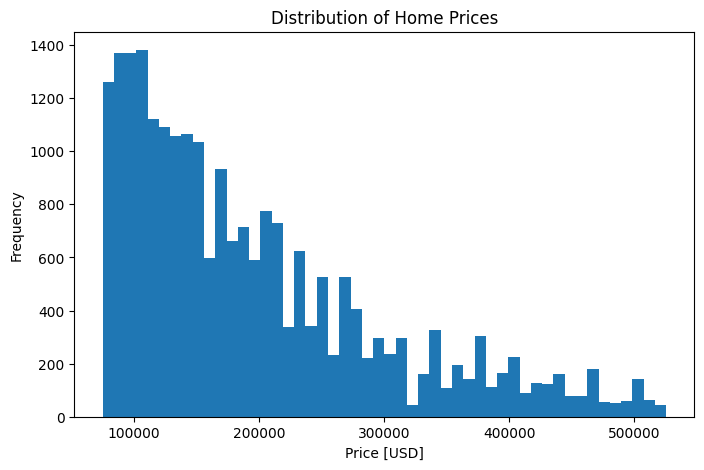

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df['price_usd'], bins=50)
plt.xlabel('Price [USD]')
plt.ylabel('Frequency')
plt.title('Distribution of Home Prices')
plt.show()



*Explanation:* Visualizes how property prices are spread. Outliers (expensive properties) can be seen clearly.

---



## 4.4 Home Size Distribution (Boxplot)



plt.figure(figsize=(8,5))
plt.boxplot(df['area_m2'], vert=False)
plt.xlabel('Area [m²]')
plt.title('Distribution of Home Sizes')
plt.show()




*Explanation:* Boxplot identifies median, quartiles, and potential outliers in home sizes.

---



# 5. Region Analysis



## 5.1 Mean Price by Region


region
Southeast       208996.762778
South           189012.345265
Northeast       185422.985441
North           181308.958207
Central-West    178596.283663
Name: price_usd, dtype: float64


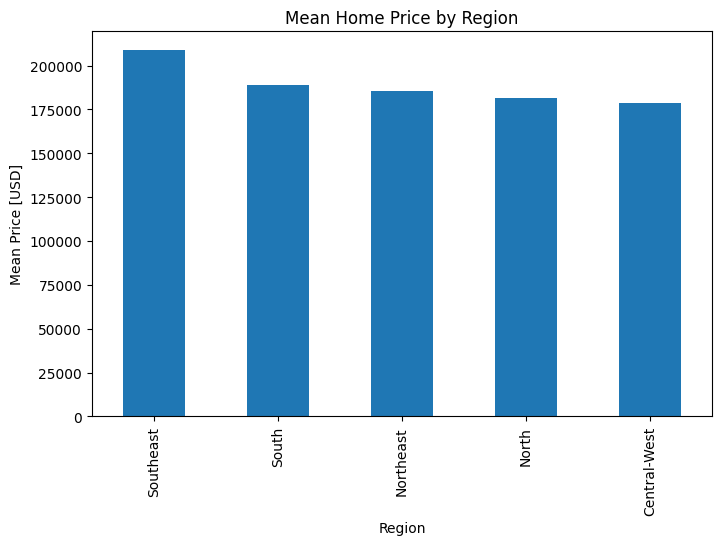

In [28]:
mean_price_by_region = df.groupby('region')['price_usd'].mean().sort_values(ascending=False)
print(mean_price_by_region)

# Bar plot
mean_price_by_region.plot(kind='bar', figsize=(8,5), title='Mean Home Price by Region')
plt.xlabel('Region')
plt.ylabel('Mean Price [USD]')
plt.show()


*Explanation:* Highlights the most expensive regions. Useful for investment insights or location-based decisions.

---



# 6. South Region Case Study



## 6.1 Homes by State


In [29]:
df_south = df[df['region'] == 'South']
homes_by_state = df_south['state'].value_counts()
print(homes_by_state)


state
Rio Grande do Sul    2643
Santa Catarina       2634
Paraná               2544
Name: count, dtype: int64



*Explanation:* Shows the number of homes per state in South, helping understand dataset coverage.



## 6.2 Correlation Between Size and Price


In [30]:
south_states_corr = (
    df_south.groupby("state")[["area_m2", "price_usd"]]
    .corr()
    .iloc[0::2, 1]
    .reset_index(level=1, drop=True)
    .to_dict()
)
print("Correlation by state in South region:", south_states_corr)


Correlation by state in South region: {'Paraná': 0.5436659935502652, 'Rio Grande do Sul': 0.577326743371769, 'Santa Catarina': 0.5068121776366797}



*Explanation:* Correlation shows how much property size affects price in each state. Some states have stronger correlation than others.

---



# 7. Key Findings



1. Property prices vary significantly across regions.
2. Larger properties generally cost more, but correlation differs by state.
3. South region shows strong correlation between area and price.
4. Price per square meter is a more reliable metric for comparison across states.

---
